# Titanic Survival Prediction

This notebook builds a machine learning model to predict which passengers survived the Titanic disaster, using the [Kaggle Titanic dataset](https://www.kaggle.com/competitions/titanic).

## Notebook outline

1. **Exploratory data analysis** — understand the data shape, types, and missing values
2. **Imputation** — fill missing `age`, `embarked`, and `cabin` values using domain-informed strategies
3. **Feature engineering** — construct new features (`title`, `family_size`, `deck`, `fare_per_person`) that give the model richer signal
4. **Pipeline** — wire all steps into a single sklearn `Pipeline` that prevents data leakage and keeps training/test transformations identical
5. **Cross-validation** — estimate real-world accuracy before submitting
6. **Submission** — generate predictions on the test set and save to `submission.csv`

## The dataset

| Column | Description |
|--------|-------------|
| `Survived` | Target: 1 = survived, 0 = did not survive |
| `Pclass` | Ticket class (1st / 2nd / 3rd) |
| `Sex`, `Age` | Passenger demographics |
| `SibSp`, `Parch` | Siblings/spouses and parents/children aboard |
| `Ticket`, `Fare` | Ticket number and price paid |
| `Cabin` | Cabin number (missing for ~77% of passengers) |
| `Embarked` | Port: S = Southampton, C = Cherbourg, Q = Queenstown |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fast')

In [2]:
data=pd.read_csv('../data/train.csv')

In [3]:
data.sample(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
522,523,0,3,"Lahoud, Mr. Sarkis",male,NaN,0,0,2624,7.2250,NaN,C
18,19,0,3,"Vander Planke, Mrs. Julius (Emelia Maria Vande...",female,31.0,1,0,345763,18.0000,NaN,S
670,671,1,2,"Brown, Mrs. Thomas William Solomon (Elizabeth ...",female,40.0,1,1,29750,39.0000,NaN,S
575,576,0,3,"Patchett, Mr. George",male,19.0,0,0,358585,14.5000,NaN,S
354,355,0,3,"Yousif, Mr. Wazli",male,NaN,0,0,2647,7.2250,NaN,C
87,88,0,3,"Slocovski, Mr. Selman Francis",male,NaN,0,0,SOTON/OQ 392086,8.0500,NaN,S
774,775,1,2,"Hocking, Mrs. Elizabeth (Eliza Needs)",female,54.0,1,3,29105,23.0000,NaN,S
544,545,0,1,"Douglas, Mr. Walter Donald",male,50.0,1,0,PC 17761,106.4250,C86,C
136,137,1,1,"Newsom, Miss. Helen Monypeny",female,19.0,0,2,11752,26.2833,D47,S
773,774,0,3,"Elias, Mr. Dibo",male,NaN,0,0,2674,7.2250,NaN,C


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Data preparation

Before exploring or modelling, we standardise column names to lowercase and drop `PassengerId` — it is just a row index with no predictive value. We also reorder columns so `survived` (the target) sits at the end, which makes the DataFrame easier to read at a glance.

In [6]:
data.columns=data.columns.str.lower()
data.drop(columns='passengerid', inplace=True)
data=data[['name', 'sex', 'age', 'pclass', 'sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked', 'survived']]
data.head()

,name,sex,age,pclass,sibsp,parch,ticket,fare,cabin,embarked,survived
0,"Braund, Mr. Owen Harris",male,22.0,3,1,0,A/5 21171,7.2500,NaN,S,0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,1,0,PC 17599,71.2833,C85,C,1
2,"Heikkinen, Miss. Laina",female,26.0,3,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,1,0,113803,53.1000,C123,S,1
4,"Allen, Mr. William Henry",male,35.0,3,0,0,373450,8.0500,NaN,S,0


## Imputing missing values

Before doing any feature engineering or model training, I want to build a preprocessing pipeline that can also be applied to the test data (used later for submission predictions). This avoids manual cleaning and ensures both datasets are transformed identically.

### Strategy for filling nulls

- **`age`**: Fill with the median age of passengers in the same class. If passengers within the same age range tend to share a similar social class, this captures those socioeconomic factors and produces more accurate imputations than using a single global median or mean.

- **`cabin`**: This column has many missing values, but dropping it entirely would discard meaningful signal — the letter in the cabin number encodes the **deck**, and decks A–C were reserved for higher-class passengers with closer access to lifeboats. Instead of dropping, I'll construct a `deck` column from the first letter and label missing entries as `"Unknown"`. If there's a real correlation between deck and class (and therefore survival), the model should pick it up.

- **`embarked`**: Only a few values are missing, so imputation here has minimal impact. To fill them, I'll look at passengers with the same fare and class, since the port of embarkation correlates with both. Historically:
  - **Southampton (S)** — the main British port, mixed class
  - **Cherbourg (C)** — a French stop that picked up many wealthy American passengers returning from Europe, skewing first class
  - **Queenstown (Q)** — the Irish stop, predominantly third-class emigrants


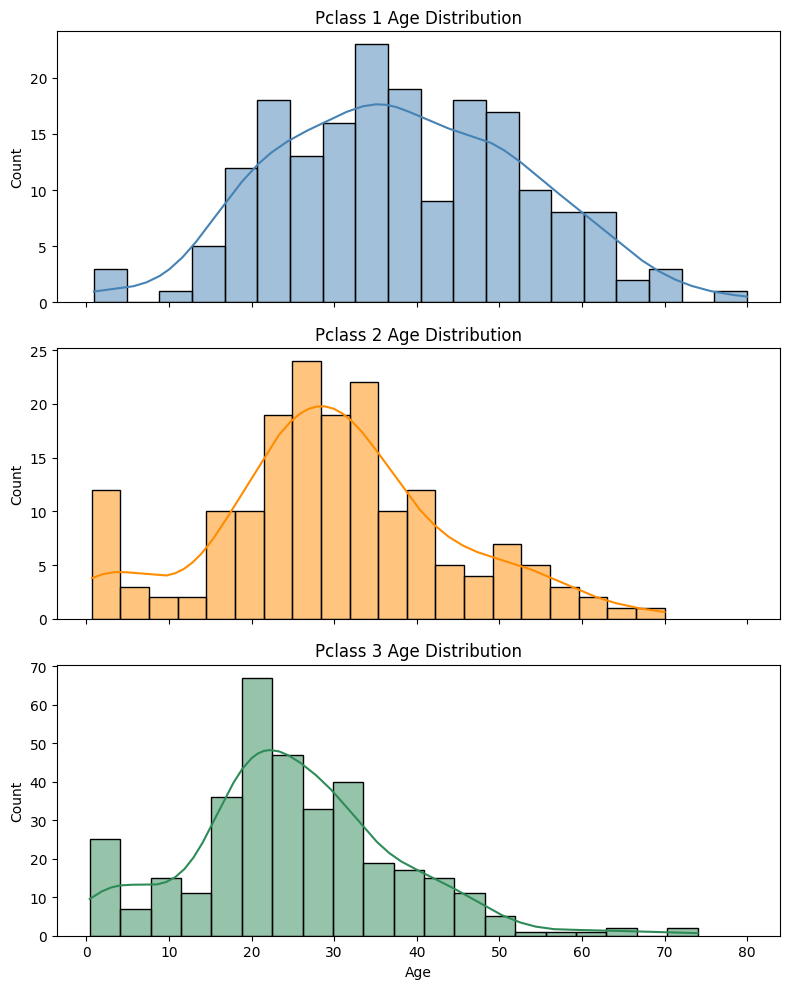

In [7]:
# looking at distribution of age across classes

class_ages = []

for num in range(3):
    class_age = data.query(f'pclass == {num + 1}')['age']
    class_ages.append(class_age)

colors = ['steelblue', 'darkorange', 'seagreen']

fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(8, 10), sharex=True)

for i, class_age in enumerate(class_ages):
    sns.histplot(class_age, kde=True, ax=axs[i], color=colors[i], bins=20)
    axs[i].set_title(f'Pclass {i+1} Age Distribution')
    axs[i].set_ylabel('Count')

axs[-1].set_xlabel('Age')
plt.tight_layout()
plt.show()


In [8]:
for i, pclass in enumerate(class_ages):
    print(f'Pclass {i+1}\nMedian age: {pclass.median()}\n')

Pclass 1
Median age: 37.0

Pclass 2
Median age: 29.0

Pclass 3
Median age: 24.0



 ### Observations from the age distributions by class

- **Pclass 1**: Roughly symmetric, centered around the late 30s. Older passengers dominate, with very few children — consistent with wealthier adult travellers.
- **Pclass 2**: Centered in the late 20s to early 30s, with a noticeable spike of young children (under 5). Likely middle-class families travelling together.
- **Pclass 3**: Strongly right-skewed, peaking in the early 20s. Also shows a cluster of young children, consistent with younger emigrant families.

The shifting peaks confirm that age and class are related — older passengers tended to be in higher classes. This justifies imputing missing ages using the **median within each class** rather than a single global median, which would systematically misrepresent both ends of the spectrum.

In [9]:
# Buiding custom class to impute missing age values
from sklearn.base import BaseEstimator, TransformerMixin

class AgeImputer(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        self.median_ages = X.groupby('pclass')['age'].median()
        return self
    
    def transform(self, X):
        X = X.copy()
        for pclass, median_age in self.median_ages.items():
            mask = (X['pclass'] == pclass) & X['age'].isna()
            X.loc[mask, 'age'] = median_age
        return X

Now I want to take a look at the missing `embarked` values, to see how I can fill them

In [10]:
data.query('embarked.isnull()')

,name,sex,age,pclass,sibsp,parch,ticket,fare,cabin,embarked,survived
61,"Icard, Miss. Amelie",female,38.0,1,0,0,113572,80.0,B28,NaN,1
829,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,1,0,0,113572,80.0,B28,NaN,1


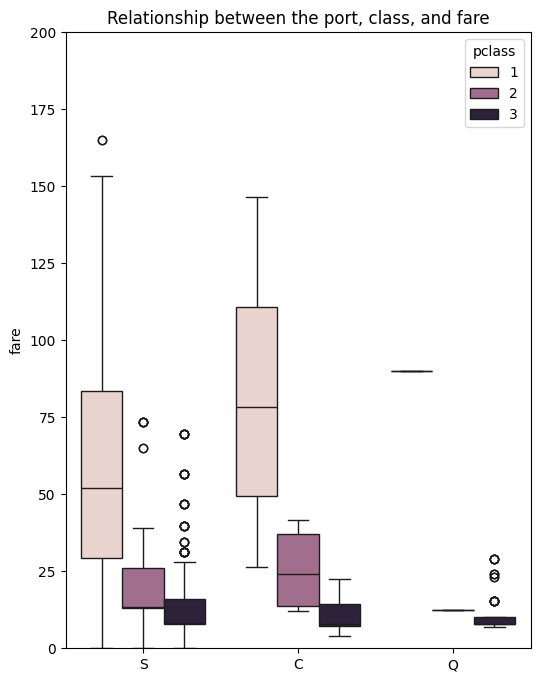

In [11]:
fare_by_class=(data.groupby(['pclass', 'embarked'])['fare'].median()).reset_index()


fig, ax=plt.subplots(figsize=(6,8))

sns.boxplot(data=data, x='embarked', y='fare', hue='pclass')
ax.set_xlabel("")
ax.set_ylim(0,200)
ax.set_title('Relationship between the port, class, and fare')

plt.show()


In [12]:
# A class to impute missing embarked 

class EmbarkedImputer(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        # Learn median fare for each (pclass, embarked) combination
        self.fare_lookup = (
            X.dropna(subset=['embarked'])
             .groupby(['pclass', 'embarked'])['fare']
             .median()
        )
        return self
    
    def transform(self, X):
        X = X.copy()
        missing = X['embarked'].isna()
        
        for idx in X[missing].index:
            pclass = X.loc[idx, 'pclass']
            fare = X.loc[idx, 'fare']
            
            # Get median fares for all ports in this passenger's class
            class_fares = self.fare_lookup.loc[pclass]
            
            # Pick the port whose median fare is closest to the passenger's fare
            closest_port = (class_fares - fare).abs().idxmin()
            X.loc[idx, 'embarked'] = closest_port
        
        return X

### Cabin → Deck

The `cabin` column is missing for ~77% of passengers, so we cannot use the raw value directly. But the first letter of a cabin number encodes the **deck** (A–G), and Titanic's deck layout mapped closely to passenger class — upper decks (A–C) were first class with the closest access to lifeboats.

Rather than dropping the column and losing all this signal, we extract two features:

- **`deck`**: the letter prefix, or `"Unknown"` if the cabin was not recorded
- **`has_cabin`**: a binary flag (1 = the passenger had a recorded cabin, 0 = not) — having any cabin record at all is itself a proxy for class and lifeboat access, independent of which deck it was on

In [13]:
class DeckExtractor(BaseEstimator, TransformerMixin):
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        X['has_cabin'] = X['cabin'].notna().astype(int)
        X['deck'] = X['cabin'].str[0].fillna('Unknown')
        X = X.drop(columns=['cabin'])
        return X

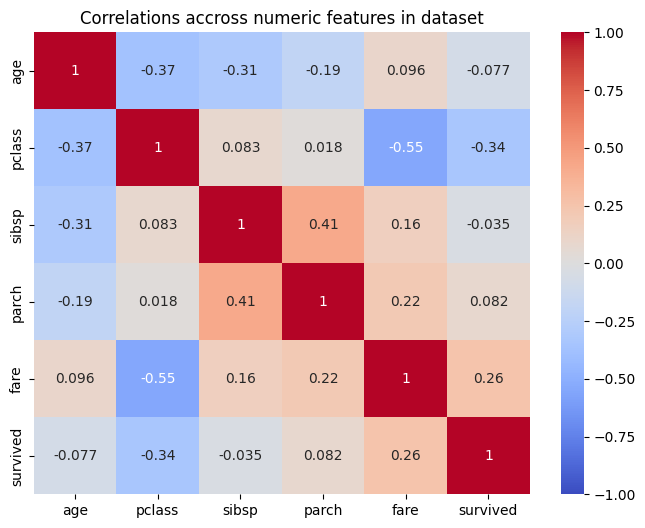

In [14]:
fig, ax=plt.subplots(figsize=(8,6))
ax.set_title("Correlations accross numeric features in dataset")
sns.heatmap(data.corr(numeric_only=True), annot=True, vmin=-1, vmax=1, cmap='coolwarm')

plt.show()


## Feature engineering

With imputation handled, the next step is to construct features that surface signal the model can use directly. While Random Forest discovers feature interactions on its own, manually engineering features that encode domain knowledge can compress information that would otherwise be scattered across multiple columns.

### Planned features

- **`title`**: The `name` column is not useful on its own, but it contains a meaningful signal in the form of the passenger's **title** (Mr, Mrs, Miss, Master, etc.).

- **`family_size`**: A combined feature derived from `sibsp + parch + 1` (including the passenger themselves). Solo travellers and very large families might have had different survival rates, so this captures non-linear group dynamics that the raw columns don't express as cleanly.

- **`is_alone`**: A binary flag derived from `family_size == 1`. Often more predictive than the raw count, since "alone vs. not alone" is a sharper boundary than gradual family size differences.

### Note on the correlation heatmap

The heatmap shows correlations between numeric features and survival, with `pclass` (-0.34) and `fare` (0.26) being the strongest linear signals. The weak correlations of `sibsp` (-0.04) and `parch` (0.08) might suggest family columns are unhelpful — but this is **misleading**. Linear correlation only captures monotonic relationships; if both very small and very large families had lower survival than mid-sized ones (a U-shaped relationship), linear correlation would show near-zero even though the signal is real. Constructing `family_size` and `is_alone` lets a tree-based model capture this non-linear pattern that the raw correlations hide.

In [15]:
data['name'].str.extract(r' ([A-Za-z]+)\.', expand=False).value_counts()

name
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

In [16]:
# A class to extract passanger titles

class TitleExtractor(BaseEstimator, TransformerMixin):
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        
        X['title'] = X['name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
        
        title_groups = {
            'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs',
            'Capt': 'Officer', 'Col': 'Officer', 'Major': 'Officer',
            'Dr': 'Professional', 'Rev': 'Professional',
            'Don': 'Royalty', 'Dona': 'Royalty', 'Jonkheer': 'Royalty',
            'Lady': 'Royalty', 'Sir': 'Royalty', 'Countess': 'Royalty',
        }
        X['title'] = X['title'].replace(title_groups)
        
        X = X.drop(columns=['name'])
        return X

In [17]:
# Creating a class to extract family features

class FamilyFeatures(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self
    def transform(self, X):
        X = X.copy()
        X['family_size'] = X['sibsp'] + X['parch'] + 1
        X['is_alone'] = (X['family_size'] == 1).astype(int)
        return X

## Investigating fare

Before adding fare to the model, I want to check two things:

1. **Distribution shape** — fare is likely heavily skewed (a few wealthy passengers paid much more than the rest), which affects how the data should be represented.
2. **Shared tickets** — fare was paid *per ticket*, not per person. Families travelling together would all show the same inflated fare value, distorting the per-passenger wealth signal.

A note on "normalization" with Random Forest: traditional scaling (subtracting the mean, dividing by std) does **nothing** for tree-based models, because trees split on thresholds and are invariant to monotonic transformations. What actually helps here is **feature engineering** — correcting the shared-ticket issue by computing fare per person.

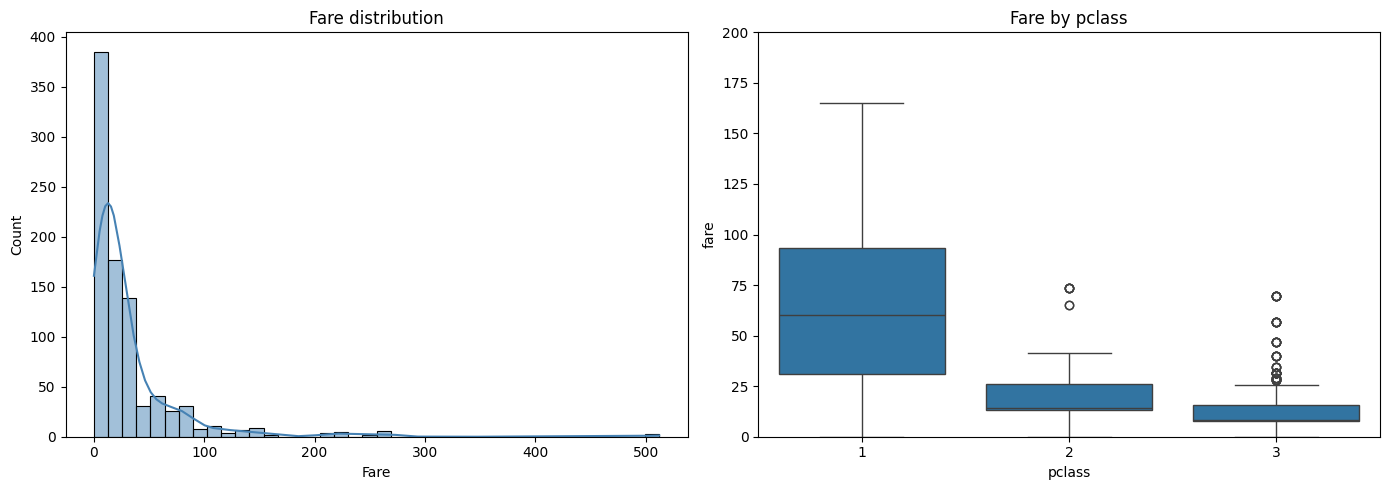

Tickets shared by 2+ passengers: 134
Largest group on one ticket: 7


In [18]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Overall fare distribution
sns.histplot(data['fare'], kde=True, ax=axs[0], bins=40, color='steelblue')
axs[0].set_title('Fare distribution')
axs[0].set_xlabel('Fare')

# Fare spread by class (capped to ignore extreme outliers)
sns.boxplot(data=data, x='pclass', y='fare', ax=axs[1])
axs[1].set_ylim(0, 200)
axs[1].set_title('Fare by pclass')

plt.tight_layout()
plt.show()

# Confirm shared tickets exist
shared_tickets = data['ticket'].value_counts()
print(f"Tickets shared by 2+ passengers: {(shared_tickets > 1).sum()}")
print(f"Largest group on one ticket: {shared_tickets.max()}")

### Observations

- The fare distribution is **heavily right-skewed**: most passengers paid less than 50, with a long tail of high fares above 100 and a few extreme outliers above 500.
- **First class has a much wider fare range** than second or third class, confirming that fare encodes wealth signal beyond what `pclass` alone captures.
- A significant number of tickets are shared by 2 or more passengers — confirming that raw fare overstates individual wealth for group travellers. Dividing by family size gives a more honest per-person fare.

This justifies engineering a `fare_per_person` feature. I'll keep the original `fare` column as well, letting the model use whichever is more informative at each split.

In [19]:
class FareEngineer(BaseEstimator, TransformerMixin):
    
    def fit(self, X, y=None):
        # Learn the size of each ticket group from training data.
        # Storing this allows us to apply the same lookup to test data,
        # rather than recomputing from a different population
        self.ticket_sizes = X['ticket'].value_counts()
        return self
    
    def transform(self, X):
        X = X.copy()
        # For each passenger, look up how many people shared their ticket.
        # Unknown tickets (present in test but not train) default to 1
        # — treating them as solo travellers
        group_size = X['ticket'].map(self.ticket_sizes).fillna(1)
        X['fare_per_person'] = X['fare'] / group_size
        return X

## Building the Pipeline

We now have six custom transformers. Instead of calling them manually in sequence, we wire them into a single `sklearn.pipeline.Pipeline`.

### Why use a Pipeline?

**Data leakage prevention** is the main reason. If you apply transformations (e.g. compute age medians) on the full training set *before* cross-validating, those medians have "seen" the validation fold — the model indirectly benefits from data it should not have access to, and your accuracy estimate is too optimistic. A Pipeline ensures every transformer's `fit` sees only the training fold of each CV split.

**Consistency** is the other reason. One `pipeline.fit(X_train, y_train)` applies every step in the correct order. `pipeline.predict(X_test)` runs the same transformations on test data automatically — no risk of forgetting a step or applying it differently.

### Structure

```
Input: name, sex, age, pclass, sibsp, parch, ticket, fare, cabin, embarked
   │
   ├─ TitleExtractor       extracts title from name, maps rare titles to groups, drops name
   ├─ FamilyFeatures       adds family_size (sibsp + parch + 1) and is_alone flag
   ├─ DeckExtractor        adds has_cabin flag + deck letter, drops cabin
   ├─ FareEngineer         adds fare_per_person (fare ÷ ticket group size)
   ├─ AgeImputer           fills missing age with per-class median (learned on train only)
   ├─ EmbarkedImputer      fills missing port using closest fare-per-class match
   ├─ FunctionTransformer  drops ticket (no longer needed after FareEngineer)
   ├─ ColumnTransformer    OrdinalEncoder on categoricals, passthrough on numerics
   ├─ SimpleImputer        safety net — fills any remaining NaN with the column median
   └─ RandomForestClassifier
```

### What is a Random Forest?

A Random Forest trains many decision trees on random subsets of the data and features, then averages their predictions. The randomness makes the ensemble more robust than any single tree — individual trees overfit, but their average generalises well. Key hyperparameters here are `n_estimators` (number of trees, set to 100) and `random_state` (for reproducibility).

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer
from sklearn.ensemble import RandomForestClassifier

# sibsp, parch, and fare are intentionally excluded here.
# family_size / is_alone already encode sibsp + parch more cleanly,
# and fare_per_person already corrects fare for shared tickets.
# Keeping the originals alongside the derived versions only adds noise.
categorical_features = ['sex', 'embarked', 'title', 'deck']
numeric_features = ['age', 'pclass', 'family_size', 'is_alone', 'has_cabin', 'fare_per_person']

preprocessor = ColumnTransformer([
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_features),
    ('num', 'passthrough', numeric_features),
])

pipeline = Pipeline([
    ('title',       TitleExtractor()),
    ('family',      FamilyFeatures()),
    ('deck',        DeckExtractor()),
    ('fare',        FareEngineer()),
    ('age',         AgeImputer()),
    ('embarked',    EmbarkedImputer()),
    ('drop_ticket', FunctionTransformer(lambda X: X.drop(columns=['ticket']), validate=False)),
    ('encode',      preprocessor),
    ('impute',      SimpleImputer(strategy='median')),
    ('clf',         RandomForestClassifier(n_estimators=200, random_state=42)),
])

print("Pipeline built successfully")

Pipeline built successfully


## Improving the model — hyperparameter tuning

The first submission scored 0.74 on Kaggle despite a 0.82 CV score. That ~8% gap is a sign of **overfitting**: the Random Forest grew trees too deep and memorised the 891 training rows rather than generalising.

Two fixes:

1. **Drop redundant features** — `sibsp`, `parch`, and raw `fare` were feeding the model the same signal twice (once raw, once in the engineered features). Keeping both adds noise that deep trees learn to split on spuriously.

2. **Tune `max_depth` and `min_samples_leaf`** — limiting how deep trees can grow forces the model to find patterns that generalise, not just memorise. We use `GridSearchCV` to search over candidate values and pick the combination with the best cross-validated accuracy.

`GridSearchCV` wraps the full pipeline and tries every combination of the parameters you give it, scoring each with cross-validation. The result is both a reliable accuracy estimate *and* the best hyperparameters — in one step.

In [21]:
from sklearn.model_selection import GridSearchCV

X = data.drop(columns=['survived'])
y = data['survived']

param_grid = {
    'clf__max_depth':        [4, 5, 6, 7, 8],
    'clf__min_samples_leaf': [1, 2, 3, 4],
}

grid_search = GridSearchCV(
    pipeline, param_grid,
    cv=5, scoring='accuracy',
    n_jobs=-1, verbose=1,
)
grid_search.fit(X, y)

print(f"\nBest params:       {grid_search.best_params_}")
print(f"Best CV accuracy:  {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits



Best params:       {'clf__max_depth': 7, 'clf__min_samples_leaf': 1}
Best CV accuracy:  0.8339


## Training on the full dataset

`GridSearchCV` with `refit=True` (the default) automatically re-fits the best parameter combination on the full training set once the search is done — so `grid_search.best_estimator_` is already trained on all 891 rows and ready to predict.

In [22]:
best_pipeline = grid_search.best_estimator_
print(f"Best pipeline ready — params: {grid_search.best_params_}")

Best pipeline ready — params: {'clf__max_depth': 7, 'clf__min_samples_leaf': 1}


## Generating the submission

We apply the trained pipeline to `test.csv` (418 passengers with no `Survived` label) and save predictions in Kaggle's required format:

```
PassengerId,Survived
892,0
893,1
...
```

`PassengerId` is carried through from the original test file so Kaggle can match predictions to passengers, but it is excluded from the features the model sees.

In [23]:
test = pd.read_csv('../data/test.csv')
passenger_ids = test['PassengerId'].copy()
test.columns = test.columns.str.lower()
test = test.drop(columns=['passengerid'])

predictions = best_pipeline.predict(test)

submission = pd.DataFrame({'PassengerId': passenger_ids, 'Survived': predictions})
submission.to_csv('../data/submission.csv', index=False)
print(f"Saved submission.csv — {len(submission)} predictions")
submission.head()

Saved submission.csv — 418 predictions


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
